# ClinVar Conflicting Variant Classification

Aquest notebook entrena els sis models de classificació per a la 
predicció de conflictes entre laboratoris (CLASS) sobre el dataset 
anotat, que inclou totes les anotacions funcionals VEP.

## Imports i càrrega de dades

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse
import shap

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)


df = pd.read_csv('../data/raw/clinvar_conflicting.csv',
                 dtype={'CHROM': str})

print(f"Shape: {df.shape}")

Shape: (65188, 46)


/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_70128/1770477880.py:17: DtypeWarning: Columns (38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/clinvar_conflicting.csv',


In [ ]:
# Vista general del conjunt de dades
print("Tipus de dades")
df.info()

Forma
(65188, 46)
Tipus de dades
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHROM               65188 non-null  object 
 1   POS                 65188 non-null  int64  
 2   REF                 65188 non-null  object 
 3   ALT                 65188 non-null  object 
 4   AF_ESP              65188 non-null  float64
 5   AF_EXAC             65188 non-null  float64
 6   AF_TGP              65188 non-null  float64
 7   CLNDISDB            65188 non-null  object 
 8   CLNDISDBINCL        167 non-null    object 
 9   CLNDN               65188 non-null  object 
 10  CLNDNINCL           167 non-null    object 
 11  CLNHGVS             65188 non-null  object 
 12  CLNSIGINCL          167 non-null    object 
 13  CLNVC               65188 non-null  object 
 14  CLNVI               27659 non-null  object 
 15  MC                  

In [41]:
df.head(5)

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,CLNDNINCL,CLNHGVS,CLNSIGINCL,CLNVC,CLNVI,MC,ORIGIN,SSR,CLASS,Allele,Consequence,IMPACT,SYMBOL,Feature_type,Feature,BIOTYPE,EXON,INTRON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,DISTANCE,STRAND,BAM_EDIT,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.1168180G>C,NaN,single_nucleotide_variant,UniProtKB_(protein):Q96L58#VAR_059317,SO:0001583|missense_variant,1,NaN,0,C,missense_variant,MODERATE,B3GALT6,Transcript,NM_080605.3,protein_coding,1/1,NaN,552,522,174,E/D,gaG/gaC,NaN,1.0,NaN,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,NaN,NC_000001.10:g.1470752G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:616101.0001|UniProtKB_(pr...,SO:0001583|missense_variant,1,NaN,0,A,missense_variant,MODERATE,TMEM240,Transcript,NM_001114748.1,protein_coding,4/4,NaN,523,509,170,P/L,cCg/cTg,NaN,-1.0,OK,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,NaN,NC_000001.10:g.1737942A>G,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:139380.0002|UniProtKB_(pr...,"SO:0001583|missense_variant,SO:0001623|5_prime...",35,NaN,1,G,missense_variant,MODERATE,GNB1,Transcript,NM_002074.4,protein_coding,6/12,NaN,632,239,80,I/T,aTc/aCc,NaN,-1.0,OK,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,NaN,NC_000001.10:g.2160305G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0004|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,A,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/S,Ggc/Agc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,NaN,NC_000001.10:g.2160305G>T,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0005|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,T,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/C,Ggc/Tgc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0


## Distribucio de la variable objectiu (CLASS)

El grafic mostra un desbalanceig on **CLASS=0** es majoritaria (~75%) i **CLASS=1** representa ~25%.


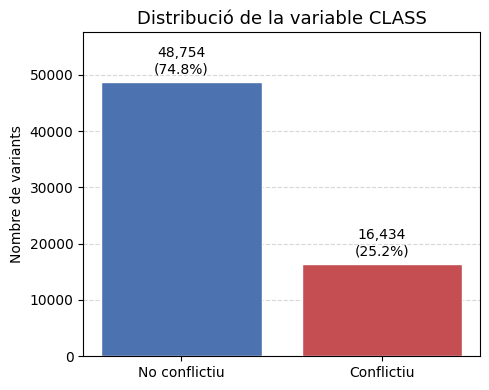

In [11]:
# Distribució de la variable objectiu (CLASS)
CLASS_LABELS = {0: "No conflictiu", 1: "Conflictiu"}
COLORS = ["#4C72B0", "#C44E52"]

counts = df["CLASS"].value_counts().sort_index()
labels = [CLASS_LABELS[i] for i in counts.index]
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(labels, counts.values, color=COLORS, edgecolor="white")
for bar, n, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.02,
            f"{n:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Distribució de la variable CLASS", fontsize=13)
ax.set_ylabel("Nombre de variants")
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Anàlisi de valors nuls

L’anàlisi dels valors nuls permet avaluar la qualitat i completitud del dataset. El gràfic de percentatge de valors absents mostra que diverses variables presenten una proporció molt elevada de missing values, incloent columnes amb pràcticament absència total d’informació. Per aquest motiu, es defineix un llindar del 95% de missing per identificar variables candidates a ser descartades en etapes posteriors.


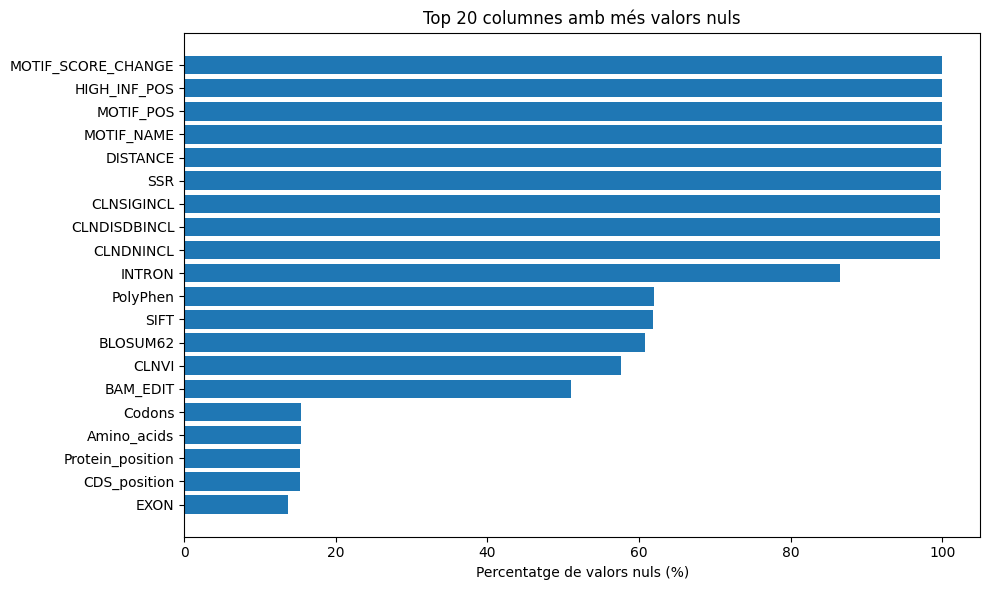

Columnes amb >95.0% valors nuls: 9
['MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME', 'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL']


In [12]:
# Valors nuls globals
missing_tbl = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_%")
)
missing_tbl["dtype"] = df.dtypes.astype(str)
missing_tbl["nunique"] = df.nunique(dropna=True)
missing_tbl["n_missing"] = df.isna().sum()

# Principals columnes amb mes valors nuls
top_n = 20
top_missing = missing_tbl[missing_tbl["missing_%"] > 0].head(top_n).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index[::-1], top_missing["missing_%"][::-1])
plt.xlabel("Percentatge de valors nuls (%)")
plt.title(f"Top {top_n} columnes amb més valors nuls")
plt.tight_layout()
plt.show()

# Columnes que superen el llindar
DROP_MISSING_THRESHOLD = 95.0
cols_drop_missing = missing_tbl.index[missing_tbl["missing_%"] > DROP_MISSING_THRESHOLD].tolist()
print(f"Columnes amb >{DROP_MISSING_THRESHOLD}% valors nuls: {len(cols_drop_missing)}")
print(cols_drop_missing[:30])



## Particio de dades (train/validation/test)

Es defineix una particio fixa per garantir comparacions justes entre models:
- 90% per **train_val** i 10% per **test**
- mateixa **random_state** en tots els splits

In [42]:

TARGET_COL = "CLASS"
RANDOM_STATE = 42
TEST_SIZE = 0.10

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 90% train_val, 10% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

## Preprocessament
Es construeix un pipeline diferenciat per tipus de variable:

- **Variables numèriques**: imputació amb mediana + normalització 
  amb `StandardScaler`.
- **Variables categòriques**: imputació amb la moda + codificació 
  amb `OneHotEncoder` (`min_frequency=20` per agrupar categories 
  poc freqüents en una sola categoria comuna).

També s'eliminen les 9 columnes amb més del 95% de valors nuls 
identificades anteriorment.

In [ ]:

cols_high_missing = [
    'MOTIF_SCORE_CHANGE',
    'HIGH_INF_POS',
    'MOTIF_POS',
    'MOTIF_NAME',
    'DISTANCE',
    'SSR',
    'CLNSIGINCL',
    'CLNDISDBINCL',
    'CLNDNINCL'
]

# Eliminem les columnes amb molt missing dels conjunts que realment fem servir
X_train_val = X_train_val.drop(columns=cols_high_missing, errors="ignore")
X_test = X_test.drop(columns=cols_high_missing, errors="ignore")

# Columnes numèriques i categòriques definides sobre train_val
num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val.select_dtypes(exclude=np.number).columns.tolist()

# Transformadors per a les columnes numèriques i categòriques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


## LinearSVC

Màquina de vectors de suport amb kernel lineal. S'optimitza el 
paràmetre `C` de regularització i el `class_weight` per gestionar 
el desbalanceig.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.01, 'model__class_weight': None}
Millor CV ROC AUC:  0.7418

Test ROC AUC: 0.7431
Confusion matrix:
[[4669  207]
 [1350  293]]


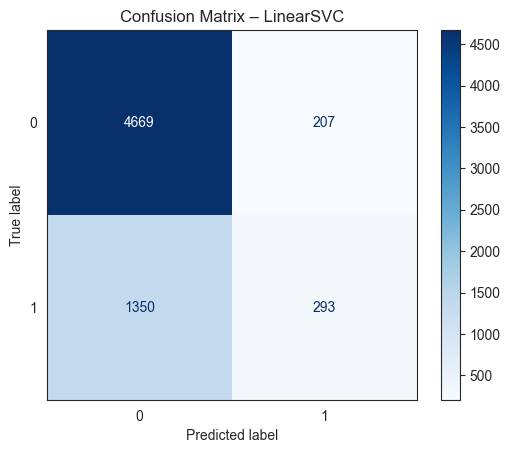

In [ ]:

# Model base
linear_svm = LinearSVC(
    random_state=42,
    max_iter=100000,
    dual=False,
    loss="squared_hinge"
)

# Pipeline preprocessament + model
pipeline_linsvm = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", linear_svm)
])

# Cerca d'hiperparàmetres
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_linsvm,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)


param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svm = GridSearchCV(
    estimator=pipeline_linsvm,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_val, y_train_val)

# Resultats de la CV
print(f"Millors paràmetres: {grid_svm.best_params_}")
print(f"Millor CV ROC AUC:  {grid_svm.best_score_:.4f}")

# Avaluació final al test
best_model = grid_svm.best_estimator_

test_scores = best_model.decision_function(X_test)
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, test_scores)
cm_svm = confusion_matrix(y_test, y_test_pred)

print(f"\nTest ROC AUC: {auc_svm:.4f}")
print(f"Confusion matrix:\n{cm_svm}")

ConfusionMatrixDisplay(confusion_matrix=cm_svm).plot(cmap="Blues")
plt.title("Confusion Matrix – LinearSVC")

auc_svm = roc_auc_score(y_test, test_scores)


## Logística L2 (Ridge)
Regressió logística amb regularització L2. Penalitza els 
coeficients grans però no els porta a zero.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': None}
Millor CV ROC AUC:  0.7488

Test ROC AUC: 0.7493
Confusion matrix:
[[4508  368]
 [1222  421]]


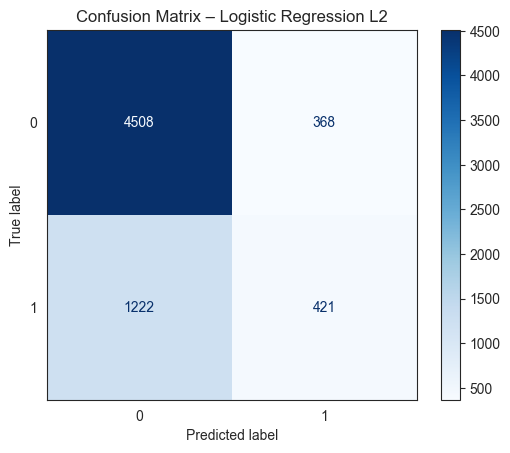

In [ ]:
# Model base
logreg_l2 = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)
# Pipeline preprocessament + model
pipeline_logreg_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", logreg_l2)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_logreg_l2,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l2 = GridSearchCV(
    estimator=pipeline_logreg_l2,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_l2.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_l2.best_params_}")
print(f"Millor CV ROC AUC:  {grid_l2.best_score_:.4f}")

# Avaluació final al test
best_model = grid_l2.best_estimator_
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)
auc_l2 = roc_auc_score(y_test, y_test_proba)
cm_l2 = confusion_matrix(y_test, y_test_pred)

print(f"\nTest ROC AUC: {auc_l2:.4f}")
print(f"Confusion matrix:\n{cm_l2}")

ConfusionMatrixDisplay(confusion_matrix=cm_l2).plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression L2")
plt.show()

## Logística L1 (Lasso)
Regressió logística amb regularització L1. Actua simultàniament 
com a mecanisme de selecció de variables, ja que porta a zero els 
coeficients menys informatius.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 1.0, 'model__class_weight': None}
Millor CV ROC AUC:  0.7429

Test ROC AUC: 0.7474
Confusion matrix:
[[4367  509]
 [1114  529]]


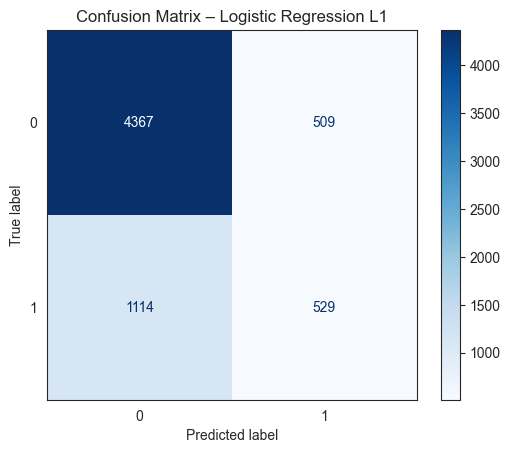

In [ ]:
# Model base
logreg_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_logreg_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", logreg_l1)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_logreg_l1,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l1 = GridSearchCV(
    estimator=pipeline_logreg_l1,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_l1.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_l1.best_params_}")
print(f"Millor CV ROC AUC:  {grid_l1.best_score_:.4f}")

# Avaluació final al test
best_model = grid_l1.best_estimator_

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)
auc_l1 = roc_auc_score(y_test, y_test_proba)
cm_l1 = confusion_matrix(y_test, y_test_pred)

print(f"\nTest ROC AUC: {auc_l1:.4f}")
print(f"Confusion matrix:\n{cm_l1}")

ConfusionMatrixDisplay(confusion_matrix=cm_l1).plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression L1")
plt.show()

## Decision Tree
Arbre de decisió. S'optimitza la profunditat màxima, la mida 
mínima dels nodes i el `class_weight`.

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Millor CV ROC AUC:  0.7579

Test ROC AUC: 0.7196
Confusion matrix:
[[3591 1285]
 [ 611 1032]]


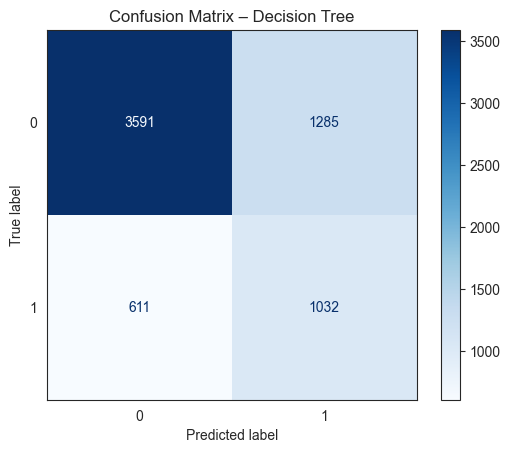

In [ ]:
# Model base
dt_binary = DecisionTreeClassifier(
    random_state=42
)

# Pipeline preprocessament + model
pipeline_dt_binary = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt_binary)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline CV score
scores = cross_val_score(
    pipeline_dt_binary,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Cerca d'hiperparàmetres
param_grid = {
    "model__max_depth":         [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf":  [1, 5, 10],
    "model__class_weight":      [None, "balanced"]
}

grid_dt_binary = GridSearchCV(
    estimator=pipeline_dt_binary,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_dt_binary.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_dt_binary.best_params_}")
print(f"Millor CV ROC AUC:  {grid_dt_binary.best_score_:.4f}")

# Avaluació final al test
best_model = grid_dt_binary.best_estimator_
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)
auc_dt_binary = roc_auc_score(y_test, y_test_proba)
cm_dt = confusion_matrix(y_test, y_test_pred)

print(f"\nTest ROC AUC: {auc_dt_binary:.4f}")
print(f"Confusion matrix:\n{cm_dt}")

ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot(cmap="Blues")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

## Random Forest
Ensemble de múltiples arbres de decisió amb mostreig aleatori 
(`bootstrap=True`) i submostreig de variables a cada divisió.


Model inicial, ROC AUC per fold: [0.81043073 0.81100981 0.81552759 0.80820155 0.81297059]
ROC AUC mitjà: 0.8116280537569471
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Millors paràmetres: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 0.3, 'model__max_depth': 30, 'model__class_weight': None}
Millor CV ROC AUC: 0.8140363556963015
Resultats del test ROC AUC: 0.8269121067975757
Confusion matrix:
 [[4665  211]
 [1168  475]]


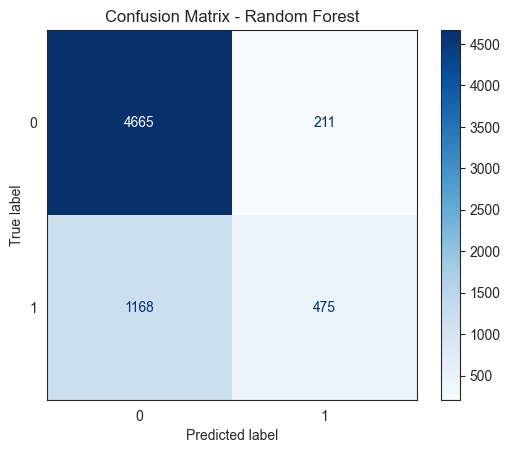

In [ ]:
# Model base
rf_binary = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Pipeline preprocessament + model
pipeline_rf_binary = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf_binary)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_rf_binary,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Distribució d'hiperparàmetres per a RandomizedSearchCV
param_dist = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

random_search_rf_binary = RandomizedSearchCV(
    estimator=pipeline_rf_binary,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)
random_search_rf_binary.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_rf_binary.best_params_}")
print(f"Millor CV ROC AUC:  {random_search_rf_binary.best_score_:.4f}")

# Avaluació final al test
best_model_rf_binary = random_search_rf_binary.best_estimator_
y_test_proba = best_model_rf_binary.predict_proba(X_test)[:, 1]
y_pred       = best_model_rf_binary.predict(X_test)

auc_rf_binary = roc_auc_score(y_test, y_test_proba)
cm_rf = confusion_matrix(y_test, y_pred)

print(f"\nTest ROC AUC: {auc_rf_binary:.4f}")
print(f"Confusion matrix:\n{cm_rf}")

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Blues")
plt.title("Confusion Matrix – Random Forest")
plt.show()

## MLP (Multilayer Perceptron)
Xarxa neuronal multicapa amb activació ReLU i optimitzador Adam. 
S'aplica `early_stopping`  que atura l'entrenament quan el rendiment 
en validació deixa de millorar per evitar el sobreajustament.

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Millors paràmetres: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}
Millor CV ROC AUC: 0.7594953476892968
Resultats del test ROC AUC: 0.7632500872521055
Confusion matrix:
 [[4544  332]
 [1200  443]]


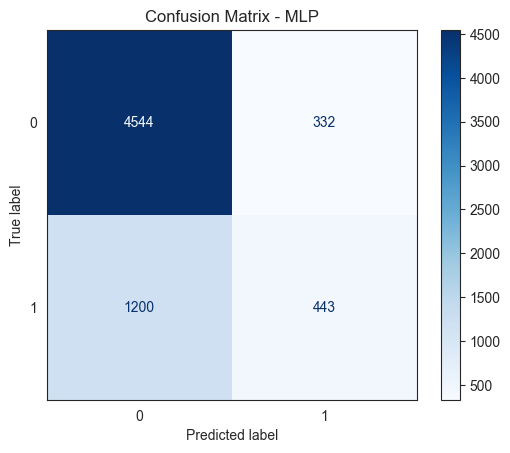

In [ ]:
# Model base
mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=500,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_mlp = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

grid_mlp = GridSearchCV(
    pipeline_mlp,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

grid_mlp.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_mlp.best_params_}")
print(f"Millor CV ROC AUC:  {grid_mlp.best_score_:.4f}")

best_mlp = grid_mlp.best_estimator_
y_test_proba = best_mlp.predict_proba(X_test)[:, 1]
y_test_pred = best_mlp.predict(X_test)
auc_mlp = roc_auc_score(y_test, y_test_proba)
cm_mlp = confusion_matrix(y_test, y_test_pred)

print(f"\nTest ROC AUC: {auc_mlp:.4f}")
print(f"Confusion matrix:\n{cm_mlp}")

ConfusionMatrixDisplay(confusion_matrix=cm_mlp).plot(cmap="Blues")
plt.title("Confusion Matrix – MLP")
plt.show()


## Corbes ROC AUC al conjunt de test

La imatge mostra les corbes ROC dels sis models avaluats sobre el conjunt de test: LinearSVC, MLP, Logistic Regression L2, Logistic Regression L1, Decision Tree i Random Forest. 
La comparacio visual de les corbes i dels valors AUC permet identificar quin model manté el millor equilibri entre sensibilitat i especificitat en el conjunt de test.

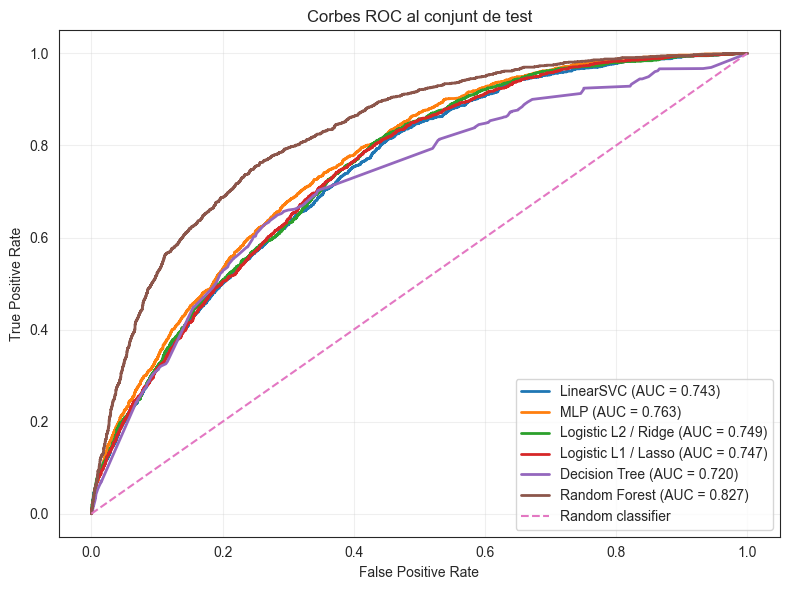

In [ ]:

# Millors models ja entrenats amb GridSearchCV
best_svm = grid_svm.best_estimator_
best_mlp = grid_mlp.best_estimator_
best_logreg_l2 = grid_l2.best_estimator_
best_logreg_l1 = grid_l1.best_estimator_
best_dt = grid_dt_binary.best_estimator_
best_rf = random_search_rf_binary.best_estimator_

# Scores/probabilitats al conjunt de test 
svm_scores = best_svm.decision_function(X_test)
mlp_scores = best_mlp.predict_proba(X_test)[:, 1]
l2_scores = best_logreg_l2.predict_proba(X_test)[:, 1]
l1_scores = best_logreg_l1.predict_proba(X_test)[:, 1]
dt_scores = best_dt.predict_proba(X_test)[:, 1]
rf_scores = best_rf.predict_proba(X_test)[:, 1]

# Punts de la corba ROC 
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_scores)
fpr_l2, tpr_l2, _ = roc_curve(y_test, l2_scores)
fpr_l1, tpr_l1, _ = roc_curve(y_test, l1_scores)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_scores)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_scores)

# AUC
auc_svm = roc_auc_score(y_test, svm_scores)
auc_mlp = roc_auc_score(y_test, mlp_scores)
auc_l2 = roc_auc_score(y_test, l2_scores)
auc_l1 = roc_auc_score(y_test, l1_scores)
auc_dt = roc_auc_score(y_test, dt_scores)
auc_rf = roc_auc_score(y_test, rf_scores)

# Plot 
plt.figure(figsize=(8, 6))

plt.plot(fpr_svm, tpr_svm, linewidth=2, label=f"LinearSVC (AUC = {auc_svm:.3f})")
plt.plot(fpr_mlp, tpr_mlp, linewidth=2, label=f"MLP (AUC = {auc_mlp:.3f})")
plt.plot(fpr_l2, tpr_l2, linewidth=2, label=f"Logistic L2 / Ridge (AUC = {auc_l2:.3f})")
plt.plot(fpr_l1, tpr_l1, linewidth=2, label=f"Logistic L1 / Lasso (AUC = {auc_l1:.3f})")
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f"Random Forest (AUC = {auc_rf:.3f})")

# línia diagonal d'atzar
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Corbes ROC al conjunt de test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretabilitat (SHAP)

Anàlisi d'interpretabilitat dels sis models entrenats mitjançant 
valors SHAP.

### Models lineals

Càlcul dels valors SHAP per als tres models lineals mitjançant 
`LinearExplainer`. Aquesta implementació és exacta i computacionalment 
molt eficient, ja que aprofita els coeficients apresos del model.

In [ ]:
# Funcions auxiliars compartides 

def clean_feature_name(name, max_len=30):
    """Elimina prefixos del ColumnTransformer i trunca noms llargs."""
    name = name.replace("cat__", "").replace("num__", "")
    return name[:max_len] + "..." if len(name) > max_len else name


def shorten_feature_name(name, max_len=35):
    """Versió extesa per a la visualització de l'arbre de decisió."""
    name = name.replace("num__", "").replace("cat__", "")
    name = name.replace("CLNDISDB_", "CLNDISDB:").replace("CLNDN_", "CLNDN:")
    return name[:max_len] + "..." if len(name) > max_len else name


def resolve_shap_class1(shap_values):
    """Retorna la matriu SHAP per a la classe 1 (Conflict) en qualsevol format."""
    if isinstance(shap_values, list):
        return shap_values[1]
    sv = np.array(shap_values)
    return sv[:, :, 1] if sv.ndim == 3 else sv


def plot_shap_bars(shap_values, feature_names, title_prefix, top_k=15):
    """Genera els dos gràfics SHAP estàndard per a qualsevol model."""
    mean_abs = np.abs(shap_values).mean(axis=0)
    mean_pos = np.where(shap_values > 0, shap_values, 0).mean(axis=0)
    mean_neg = np.where(shap_values < 0, shap_values, 0).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature":       [clean_feature_name(f) for f in feature_names],
        "mean_abs_shap": mean_abs,
        "mean_pos_shap": mean_pos,
        "mean_neg_shap": mean_neg,
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    # Gràfic 1: Top k per mitjana absoluta
    top_abs = shap_df.nlargest(top_k, "mean_abs_shap").sort_values("mean_abs_shap")
    ax1.barh(top_abs["feature"], top_abs["mean_abs_shap"], color="#4C72B0")
    ax1.set_title(f"{title_prefix} – SHAP mitjana absoluta (Top {top_k})")
    ax1.set_xlabel("Mean |SHAP value|")

    # Gràfic 2: Contribució direccional
    top_pos = shap_df.nlargest(top_k, "mean_pos_shap").copy()
    top_neg = shap_df.nsmallest(top_k, "mean_neg_shap").copy()

    plot_df = pd.concat([
        top_pos.assign(direction="Positive")[["feature", "mean_pos_shap", "direction"]]
               .rename(columns={"mean_pos_shap": "signed_shap"}),
        top_neg.assign(direction="Negative")[["feature", "mean_neg_shap", "direction"]]
               .rename(columns={"mean_neg_shap": "signed_shap"}),
    ]).drop_duplicates(subset="feature", keep="first").sort_values("signed_shap")

    colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_df["signed_shap"]]
    ax2.barh(plot_df["feature"], plot_df["signed_shap"], color=colors)
    ax2.axvline(0, color="black", linewidth=1)
    ax2.set_title(f"{title_prefix} – Contribució direccional SHAP")
    ax2.set_xlabel("Mean SHAP value")

    plt.tight_layout()
    plt.show()

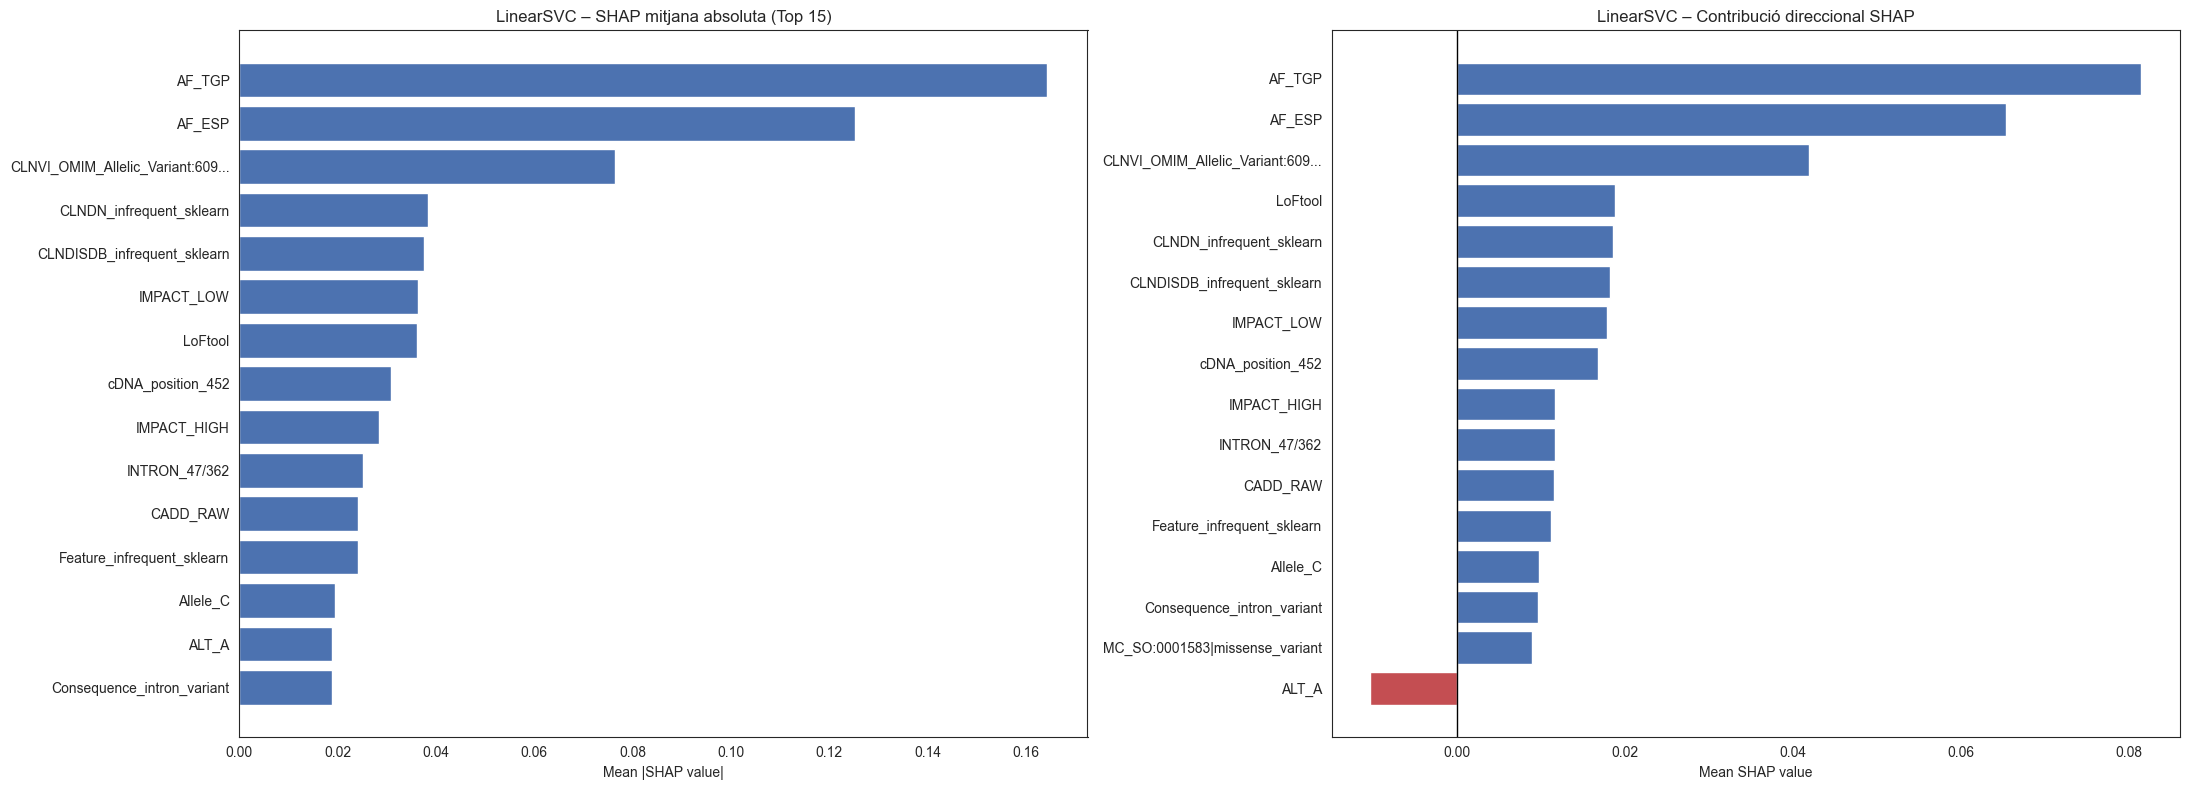

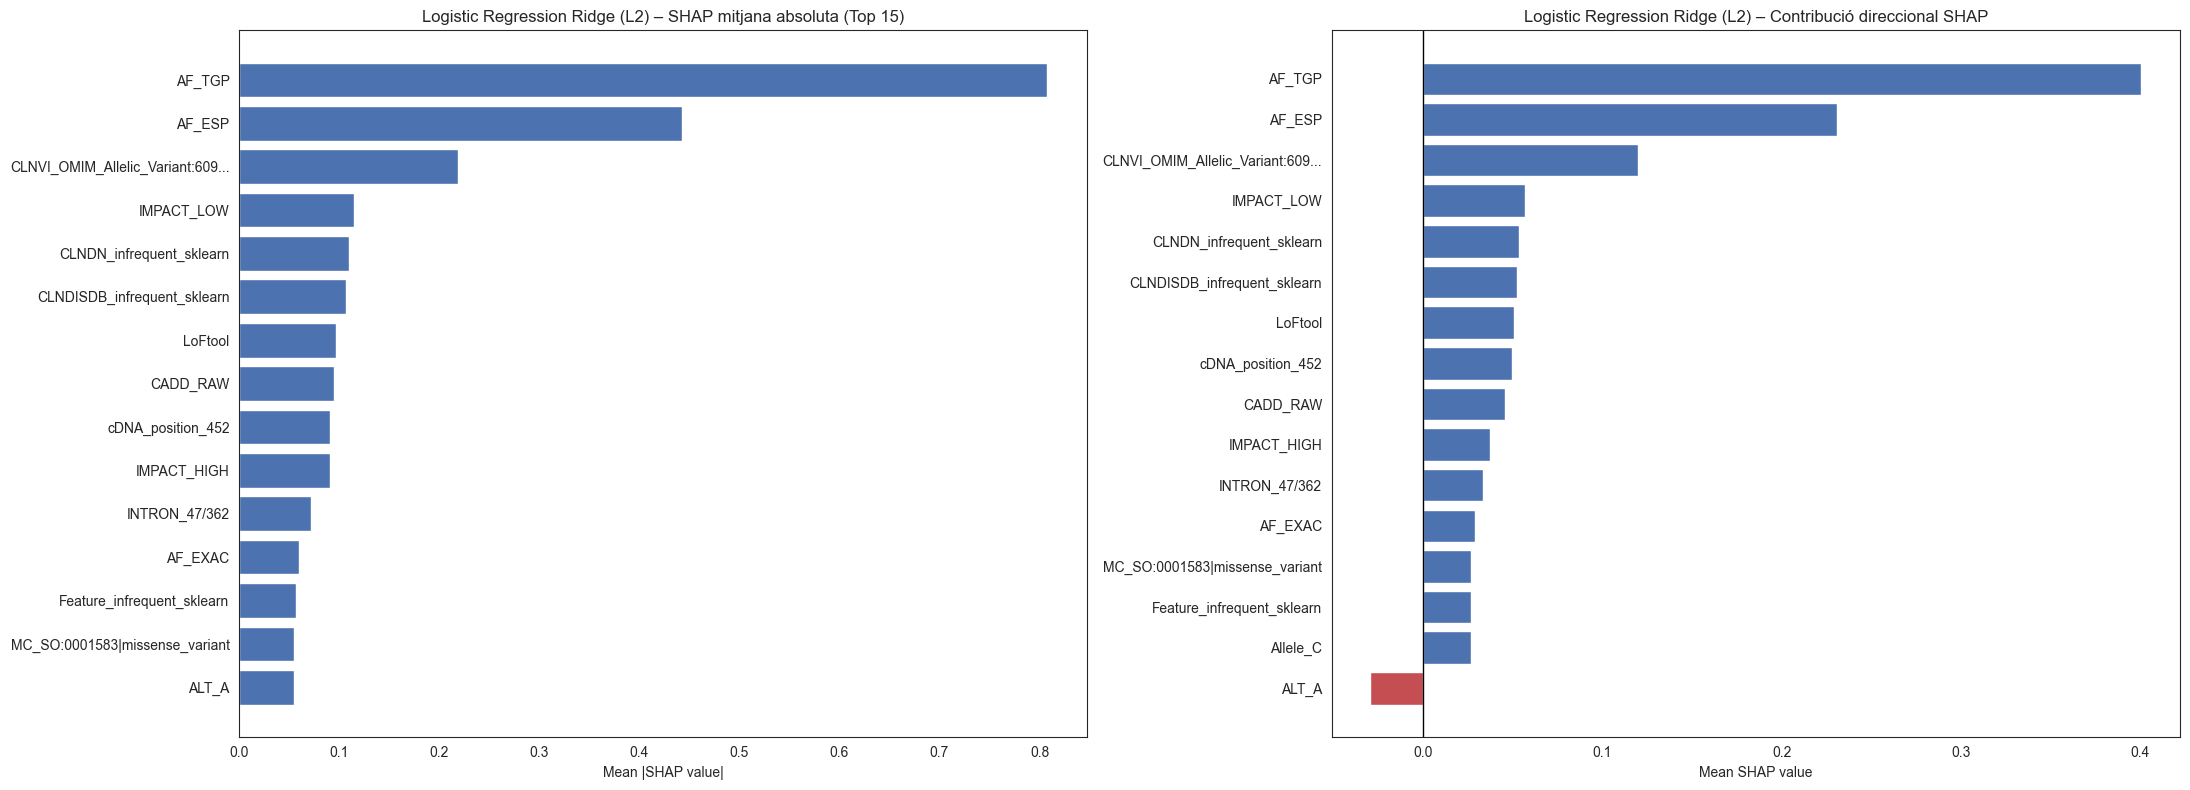

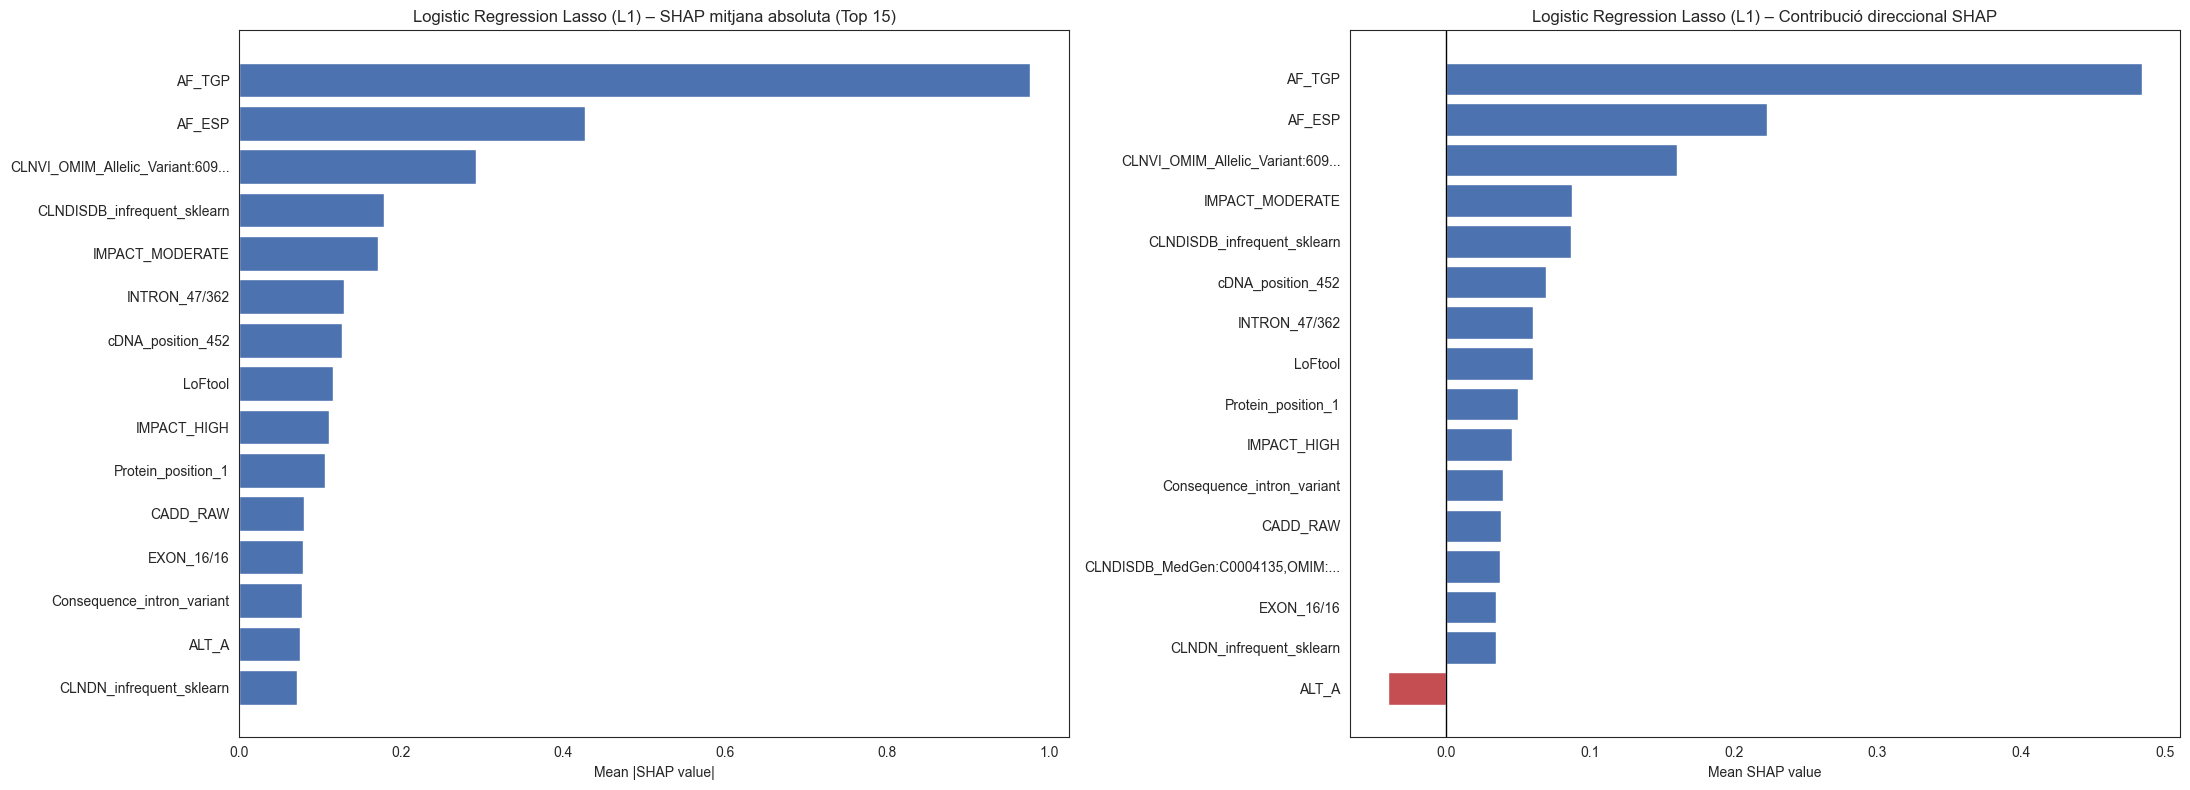

In [ ]:
# Models lineals (LinearSVC, LR-L2, LR-L1) 
X_test_lin = grid_svm.best_estimator_.named_steps["preprocess"].transform(X_test)
feature_names_lin = grid_svm.best_estimator_.named_steps["preprocess"].get_feature_names_out()

# Explainers SHAP per a models lineals
explainer_svm = shap.LinearExplainer(grid_svm.best_estimator_.named_steps["model"], X_test_lin)
explainer_l2  = shap.LinearExplainer(grid_l2.best_estimator_.named_steps["model"],  X_test_lin)
explainer_l1  = shap.LinearExplainer(grid_l1.best_estimator_.named_steps["model"],  X_test_lin)

for sv, name in [
    (explainer_svm.shap_values(X_test_lin), "LinearSVC"),
    (explainer_l2.shap_values(X_test_lin),  "Logistic Regression Ridge (L2)"),
    (explainer_l1.shap_values(X_test_lin),  "Logistic Regression Lasso (L1)"),
]:
    plot_shap_bars(sv, feature_names_lin, name)

### Decision Tree

Càlcul dels valors SHAP mitjançant `TreeExplainer`, que aprofita 
l'estructura de l'arbre per obtenir valors exactes de manera eficient.

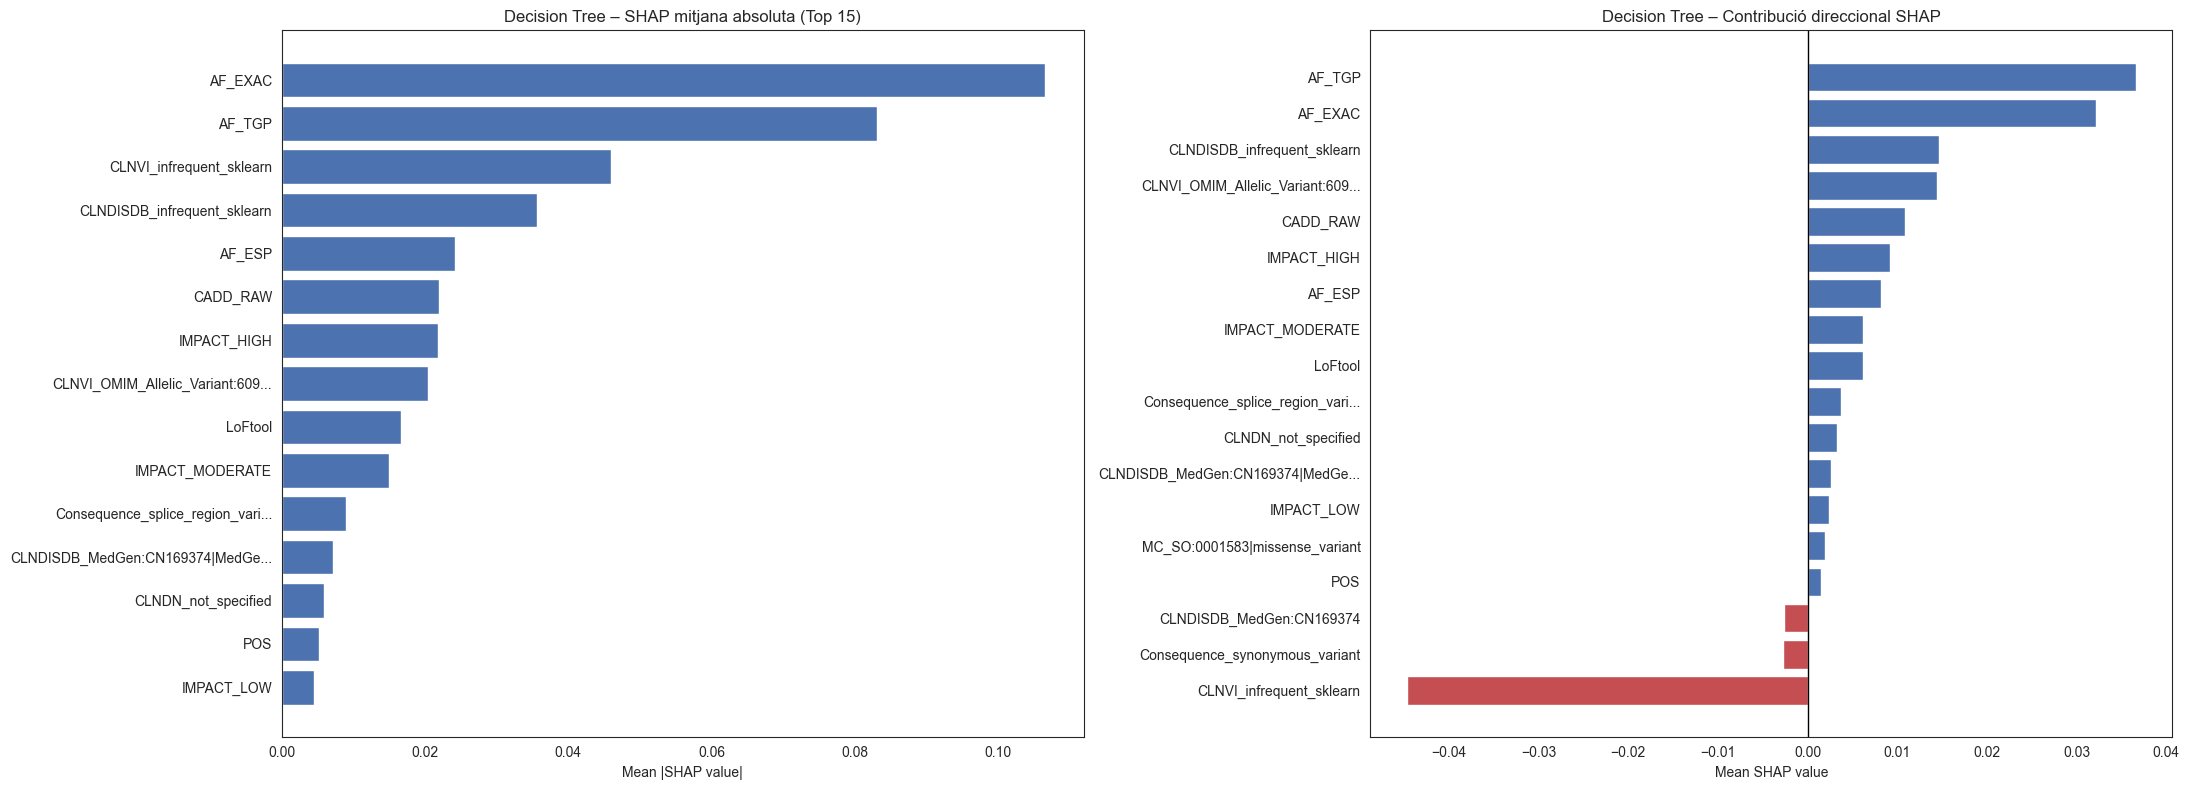

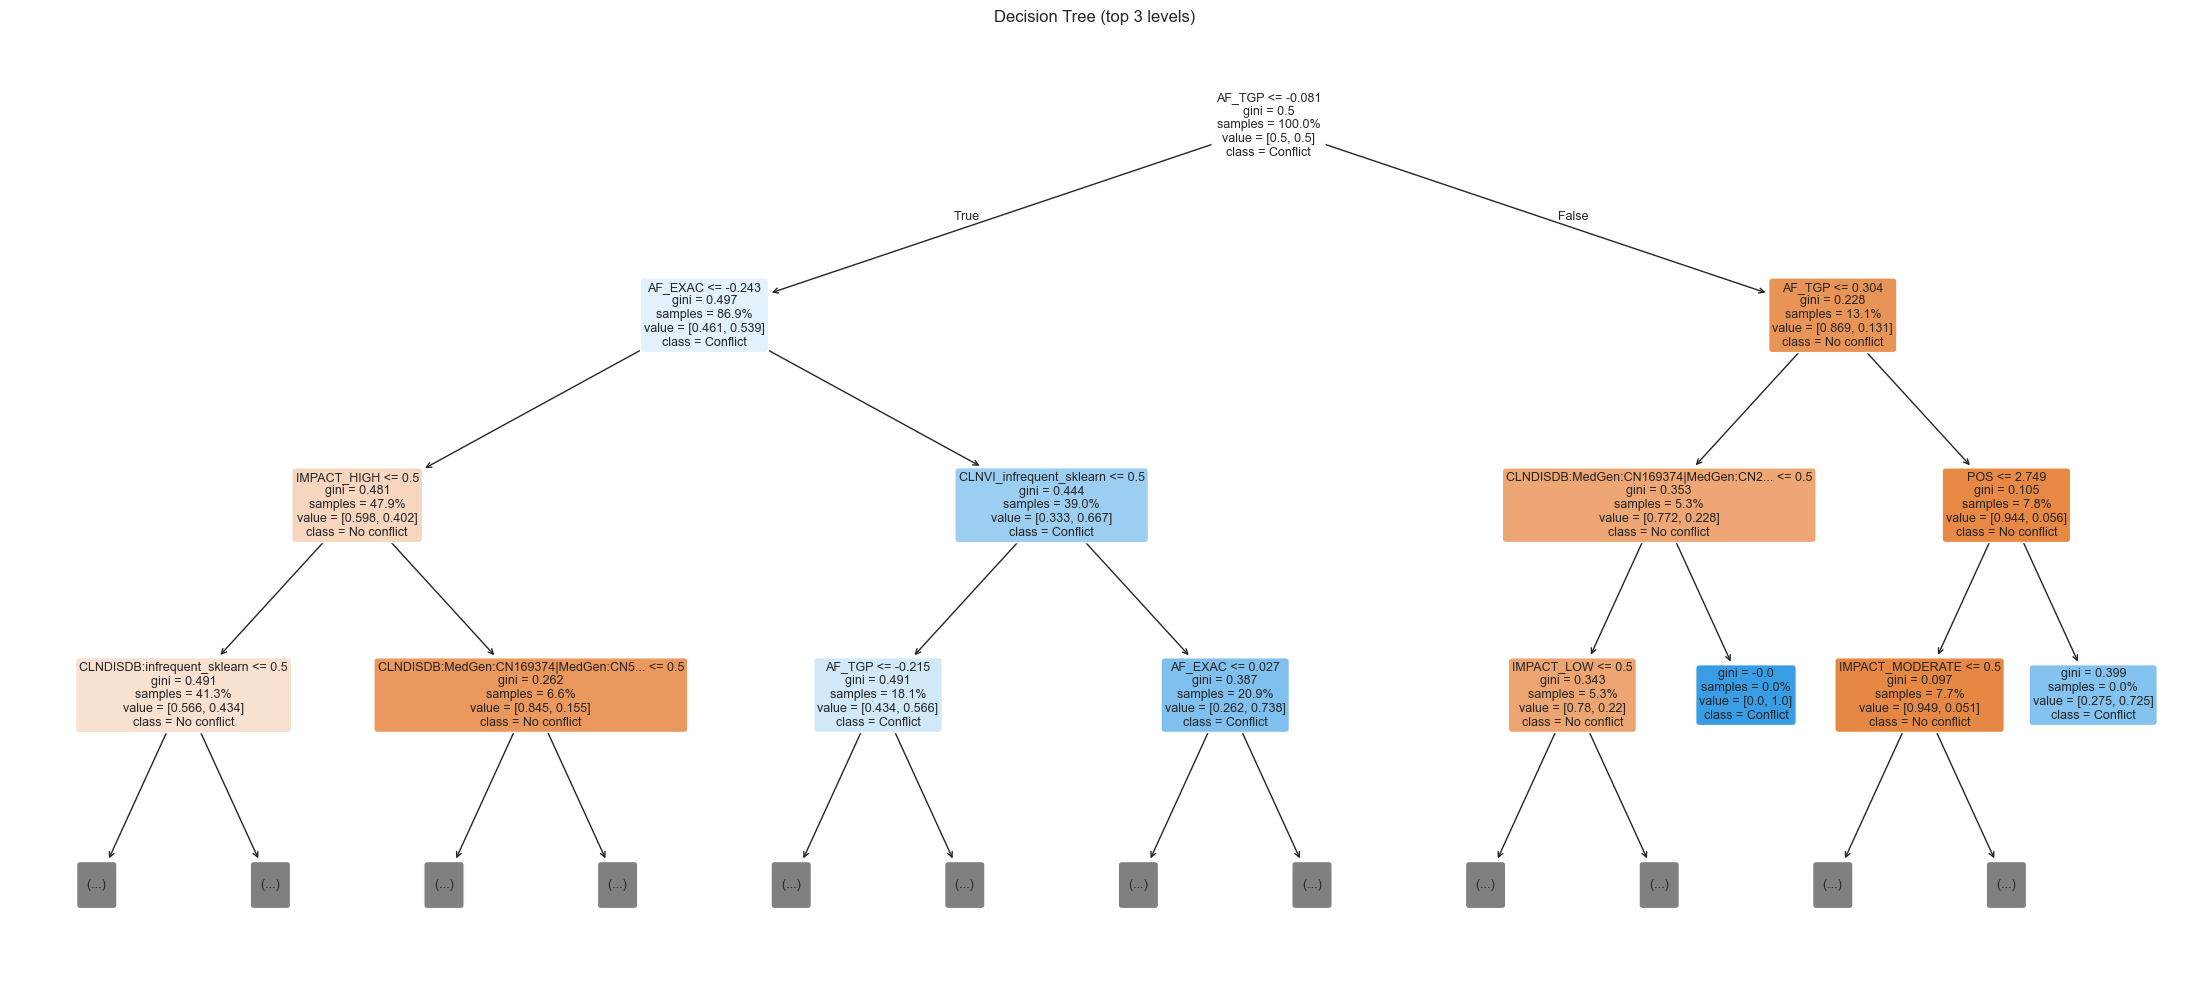

In [ ]:
 
X_test_dt = best_dt.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_dt):
    X_test_dt = X_test_dt.toarray().astype(np.float64)
else:
    X_test_dt = np.array(X_test_dt, dtype=np.float64)

feature_names_dt = best_dt.named_steps["preprocess"].get_feature_names_out()

# Explainer SHAP per a Decision Tree
explainer_dt   = shap.TreeExplainer(best_dt.named_steps["model"])
shap_values_dt = explainer_dt.shap_values(X_test_dt)
sv_dt = resolve_shap_class1(shap_values_dt)

plot_shap_bars(sv_dt, feature_names_dt, "Decision Tree")

# Estructura de l'arbre de 3 primers nivells
fig = plt.figure(figsize=(22, 10))
plot_tree(
    best_dt.named_steps["model"],
    feature_names=[shorten_feature_name(f) for f in feature_names_dt],
    class_names=["No conflict", "Conflict"],
    filled=True, rounded=True,
    max_depth=3, fontsize=9,
    impurity=True, proportion=True,
)
plt.title("Decision Tree (top 3 levels)")
plt.tight_layout()
plt.show()

### Random Forest

Càlcul dels valors SHAP mitjançant `TreeExplainer` amb aproximació 
per conjunts d'arbres. S'utilitza `approximate=True` per reduir 
el cost computacional mantenint una estimació fiable.

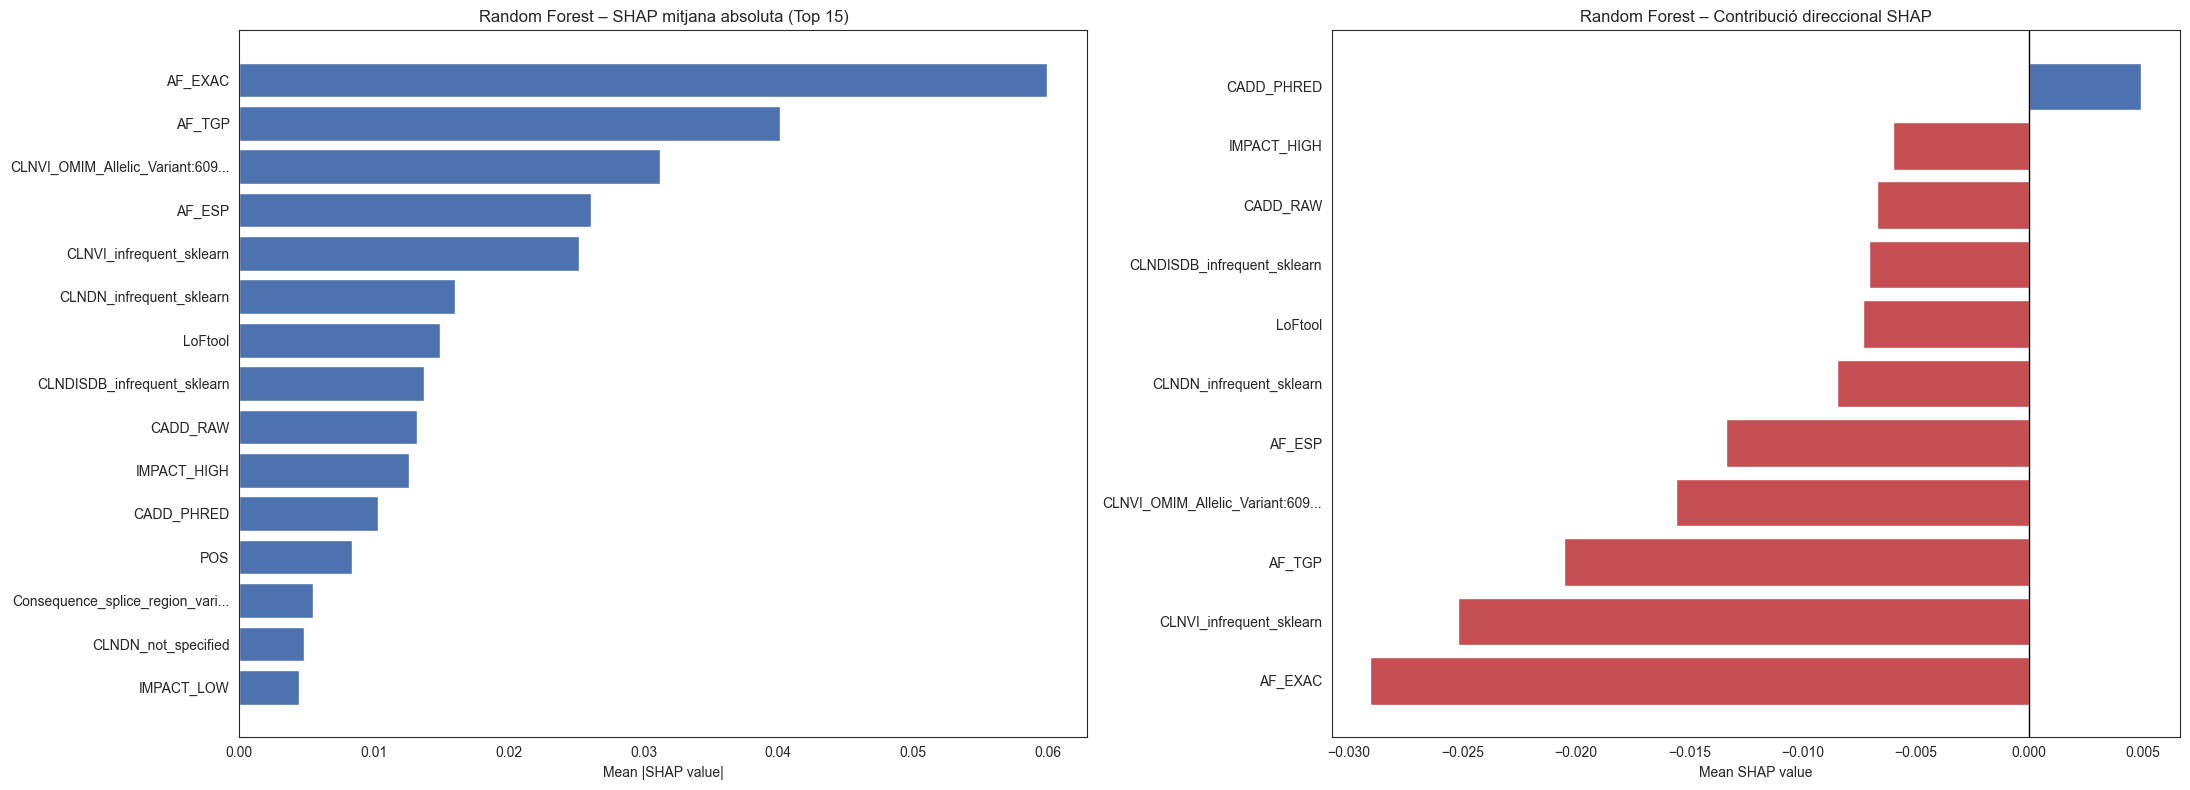

In [ ]:

# Per a Random Forest, obtenim els SHAP values de la classe 1 (Conflict) i generem els gràfics SHAP
X_test_rf = best_model_rf_binary.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_rf):
    X_test_rf = X_test_rf.toarray().astype(np.float64)
else:
    X_test_rf = np.array(X_test_rf, dtype=np.float64)

rf_model       = best_model_rf_binary.named_steps["model"]
feature_names_rf = best_model_rf_binary.named_steps["preprocess"].get_feature_names_out()

# Explainer SHAP per a Random Forest
explainer_rf   = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_rf, approximate=True, check_additivity=False)

if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
else:
    sv_rf = np.array(shap_values_rf)[:, :, 1]

# Càlcul de les mitjanes per a cada feature
mean_abs_rf = np.abs(sv_rf).mean(axis=0)
mean_pos_rf = np.where(sv_rf > 0, sv_rf, 0).mean(axis=0)
mean_neg_rf = np.where(sv_rf < 0, sv_rf, 0).mean(axis=0)

rf_shap_df = pd.DataFrame({
    "feature":       [clean_feature_name(f) for f in feature_names_rf],
    "mean_abs_shap": mean_abs_rf,
    "mean_pos_shap": mean_pos_rf,
    "mean_neg_shap": mean_neg_rf,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Gràfic 1: Top 15 per valor absolut
top_abs_rf = rf_shap_df.nlargest(15, "mean_abs_shap").sort_values("mean_abs_shap")
ax1.barh(top_abs_rf["feature"], top_abs_rf["mean_abs_shap"], color="#4C72B0")
ax1.set_title("Random Forest – SHAP mitjana absoluta (Top 15)")
ax1.set_xlabel("Mean |SHAP value|")

# Gràfic 2: Contribució direccional
top_k = 10
top_pos_rf = rf_shap_df.nlargest(top_k, "mean_pos_shap")
top_neg_rf = rf_shap_df.nsmallest(top_k, "mean_neg_shap")

plot_rf = pd.concat([
    top_pos_rf[["feature", "mean_pos_shap"]].rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_rf[["feature", "mean_neg_shap"]].rename(columns={"mean_neg_shap": "signed_shap"}),
]).sort_values("signed_shap").drop_duplicates(subset="feature", keep="first")

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_rf["signed_shap"]]
ax2.barh(plot_rf["feature"], plot_rf["signed_shap"], color=colors)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("Random Forest – Contribució direccional SHAP")
ax2.set_xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()

### MLP

Càlcul dels valors SHAP mitjançant `KernelExplainer`, l'únic 
mètode aplicable a xarxes neuronals. S'utilitza un background 
de 30 centroides obtinguts amb k-means sobre el conjunt d'entrenament.

/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
  0%|          | 0/6519 [00:00<?, ?it/s]/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib

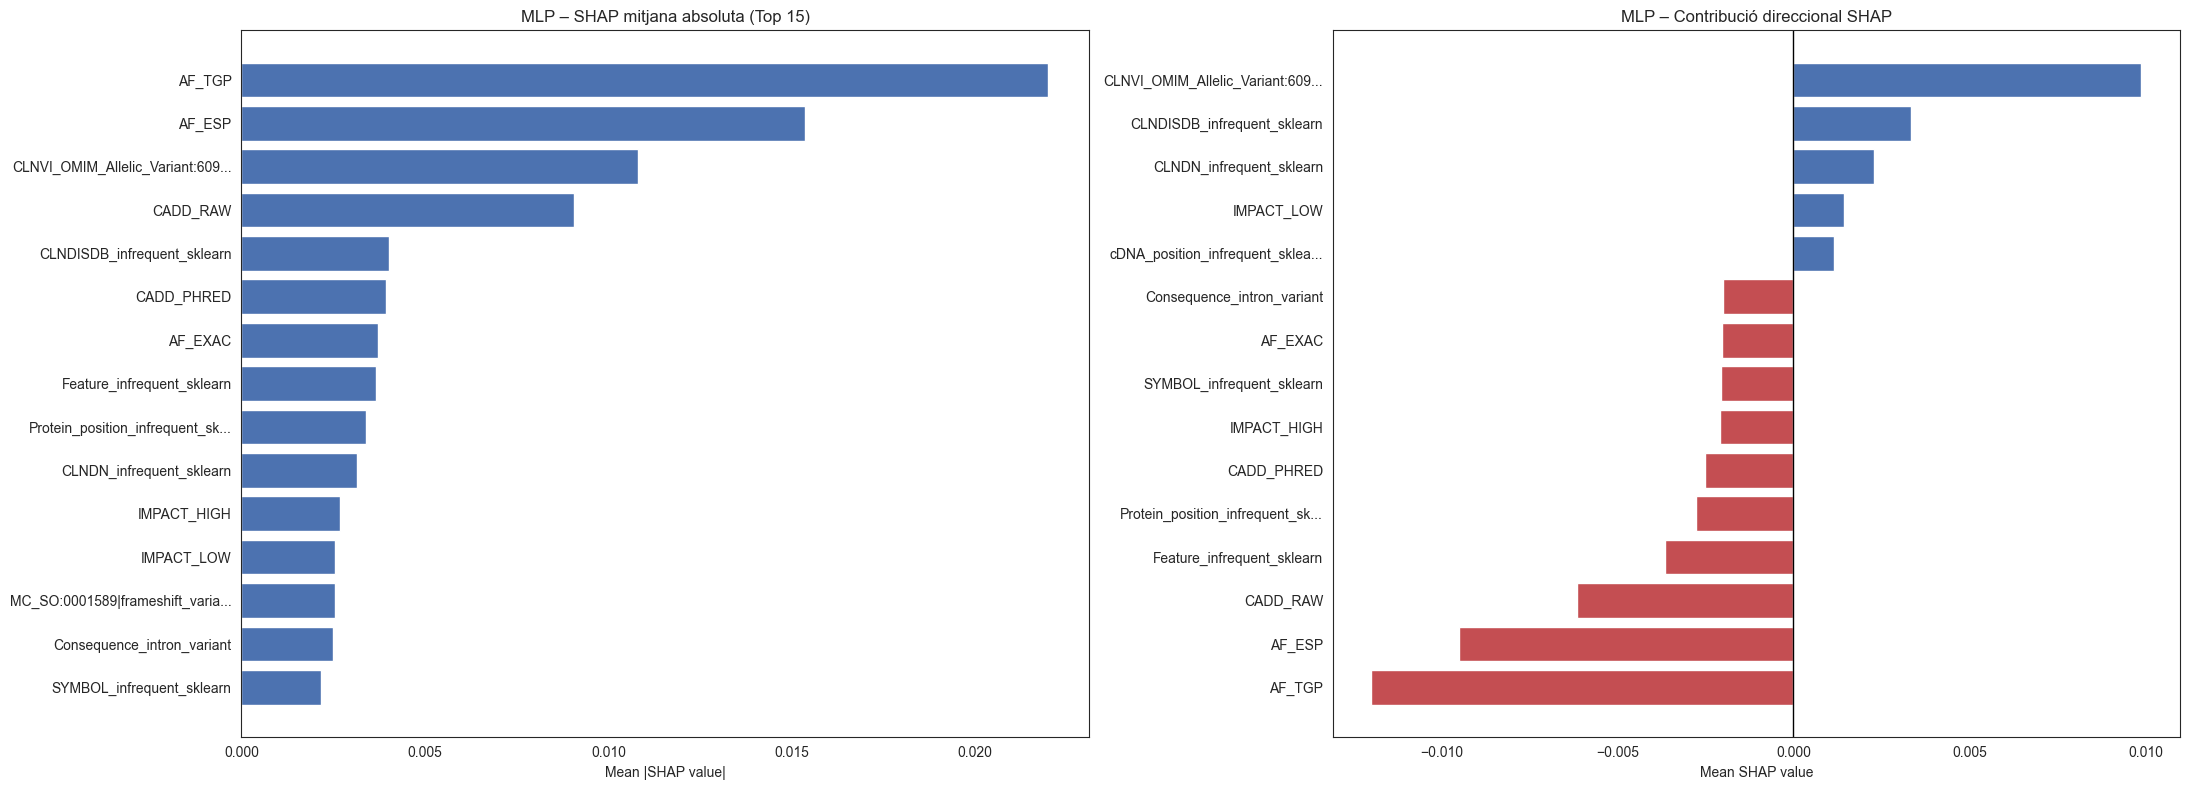

In [ ]:

# Per a MLP, utilitzem Kernel SHAP per obtenir els SHAP values de la classe 1 (Conflict) 
X_test_mlp = best_mlp.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_mlp):
    X_test_mlp = X_test_mlp.toarray().astype(np.float64)
else:
    X_test_mlp = np.array(X_test_mlp, dtype=np.float64)

# Per a Kernel SHAP, utilitzem una mostra representativa del conjunt de train_val com a background
X_train_mlp = best_mlp.named_steps["preprocess"].transform(X_train_val)
if scipy.sparse.issparse(X_train_mlp):
    X_train_mlp = X_train_mlp.toarray().astype(np.float64)
else:
    X_train_mlp = np.array(X_train_mlp, dtype=np.float64)

feature_names_mlp = best_mlp.named_steps["preprocess"].get_feature_names_out()
mlp_model = best_mlp.named_steps["model"]

# Utilitzem KMeans per seleccionar un background més representatiu i reduir el cost computacional de Kernel SHAP
background    = shap.kmeans(X_train_mlp, 30)
explainer_mlp = shap.KernelExplainer(lambda x: mlp_model.predict_proba(x)[:, 1], background)

shap_values_mlp = np.array(explainer_mlp.shap_values(X_test_mlp, nsamples=100), dtype=np.float64)

# Càlcul de les mitjanes per a cada feature
mean_abs_mlp = np.abs(shap_values_mlp).mean(axis=0)
mean_pos_mlp = np.where(shap_values_mlp > 0, shap_values_mlp, 0).mean(axis=0)
mean_neg_mlp = np.where(shap_values_mlp < 0, shap_values_mlp, 0).mean(axis=0)

mlp_shap_df = pd.DataFrame({
    "feature":       [clean_feature_name(f) for f in feature_names_mlp],
    "mean_abs_shap": mean_abs_mlp,
    "mean_pos_shap": mean_pos_mlp,
    "mean_neg_shap": mean_neg_mlp,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Gràfic 1: Top 15 per valor absolut
top_abs_mlp = mlp_shap_df.nlargest(15, "mean_abs_shap").sort_values("mean_abs_shap")
ax1.barh(top_abs_mlp["feature"], top_abs_mlp["mean_abs_shap"], color="#4C72B0")
ax1.set_title("MLP – SHAP mitjana absoluta (Top 15)")
ax1.set_xlabel("Mean |SHAP value|")

# Gràfic 2: Contribució direccional
top_k = 10
top_pos_mlp = mlp_shap_df.nlargest(top_k, "mean_pos_shap")
top_neg_mlp = mlp_shap_df.nsmallest(top_k, "mean_neg_shap")

plot_mlp = pd.concat([
    top_pos_mlp[["feature", "mean_pos_shap"]].rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_mlp[["feature", "mean_neg_shap"]].rename(columns={"mean_neg_shap": "signed_shap"}),
]).sort_values("signed_shap").drop_duplicates(subset="feature", keep="first")

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_mlp["signed_shap"]]
ax2.barh(plot_mlp["feature"], plot_mlp["signed_shap"], color=colors)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("MLP – Contribució direccional SHAP")
ax2.set_xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()

## Comparació Intrepretabilitat entre models

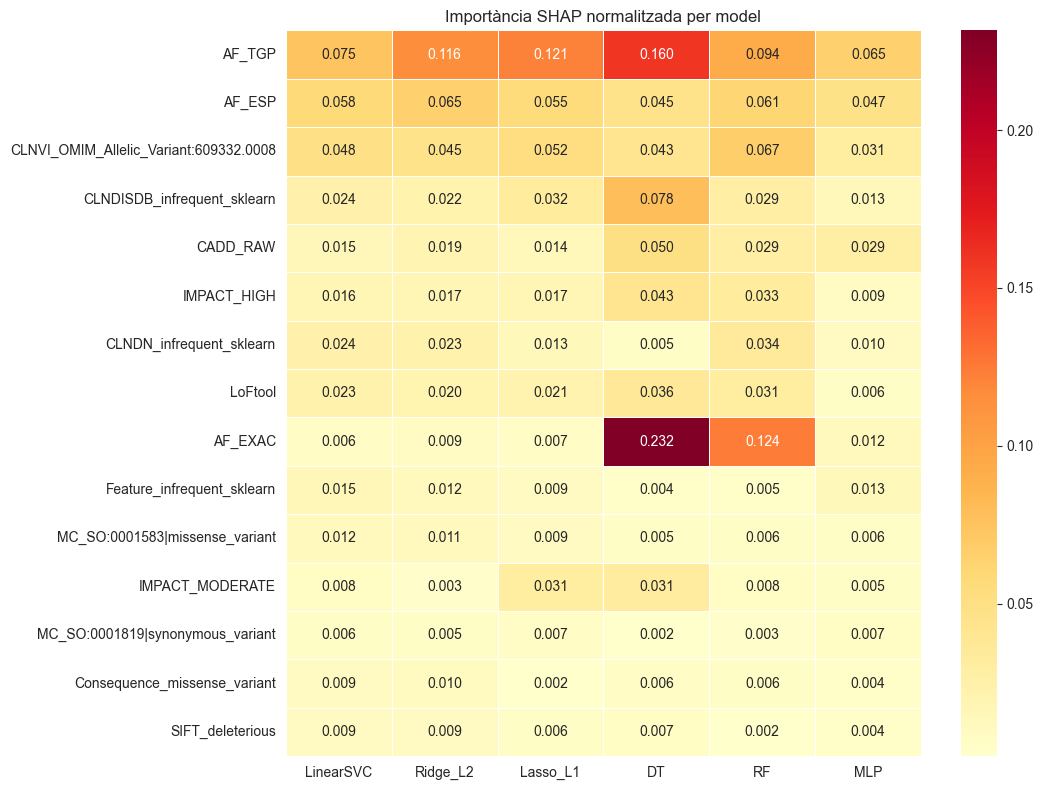

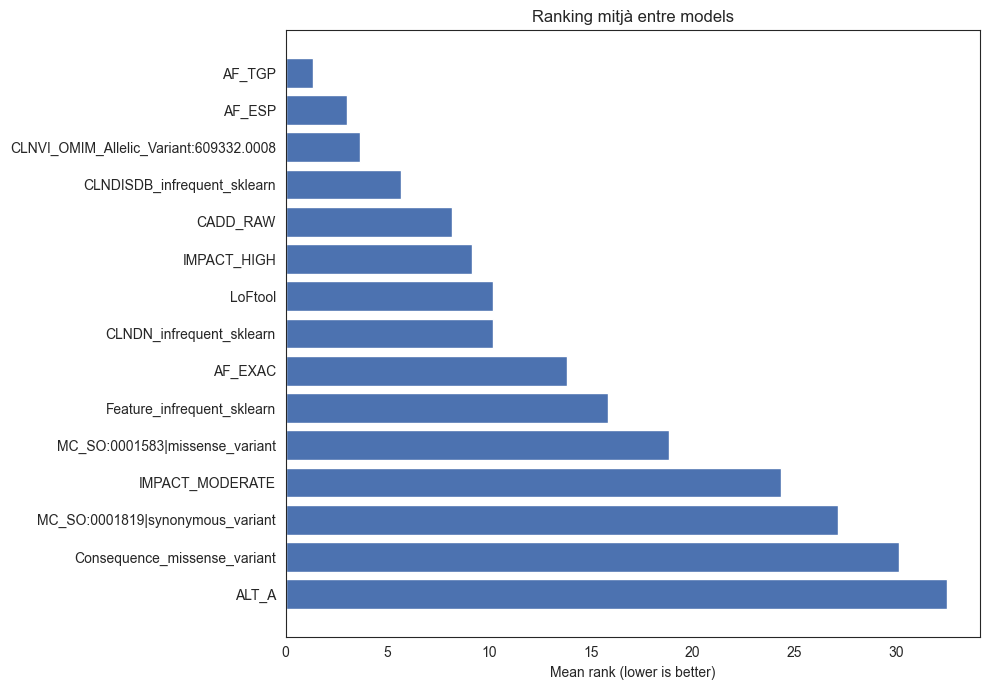

In [ ]:
# Ridge / Lasso / LinearSVC → LinearExplainer retorna 2D directament (classe 1)
sv_l2  = shap_values_l2  if not isinstance(shap_values_l2,  list) else shap_values_l2[1]
sv_l1  = shap_values_l1  if not isinstance(shap_values_l1,  list) else shap_values_l1[1]
sv_svm = shap_values_svm if not isinstance(shap_values_svm, list) else shap_values_svm[1]

# RF pot ser llista o array 3D
if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
else:
    sv_rf = shap_values_rf[:, :, 1] if shap_values_rf.ndim == 3 else shap_values_rf

# MLP KernelExplainer retorna 2D per classificació binària
sv_mlp = shap_values_mlp if shap_values_mlp.ndim == 2 else shap_values_mlp[:, :, 1]

# feature_names compartit 
feature_names_rf  = feature_names
feature_names_mlp = feature_names
feature_names_svm = feature_names


def get_normalized_shap(sv, feature_names):
    abs_sv = np.abs(sv)
    total_per_sample = abs_sv.sum(axis=1, keepdims=True)
    total_per_sample = np.where(total_per_sample == 0, 1, total_per_sample)
    normalized = abs_sv / total_per_sample
    mean_normalized = normalized.mean(axis=0)

    clean_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

    return pd.Series(mean_normalized, index=clean_names)


# Calcular per cada model
importance_svm = get_normalized_shap(sv_svm, feature_names_svm)
importance_l2  = get_normalized_shap(sv_l2,  feature_names)
importance_l1  = get_normalized_shap(sv_l1,  feature_names)
importance_dt  = get_normalized_shap(sv_dt,  feature_names_dt)
importance_rf  = get_normalized_shap(sv_rf,  feature_names_rf)
importance_mlp = get_normalized_shap(sv_mlp, feature_names_mlp)

# Ajuntar tot en un DataFrame
meta_df = pd.DataFrame({
    "LinearSVC": importance_svm,
    "Ridge_L2":  importance_l2,
    "Lasso_L1":  importance_l1,
    "DT":        importance_dt,
    "RF":        importance_rf,
    "MLP":       importance_mlp,
}).fillna(0)

# Mitjana entre models 
meta_df["mean_across_models"] = meta_df[
    ["LinearSVC", "Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]
].mean(axis=1)

# Ranking per cada model
for col in ["LinearSVC", "Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]:
    meta_df[f"rank_{col}"] = meta_df[col].rank(ascending=False).astype(int)

meta_df["mean_rank"] = meta_df[
    ["rank_LinearSVC", "rank_Ridge_L2", "rank_Lasso_L1",
     "rank_DT", "rank_RF", "rank_MLP"]
].mean(axis=1)


# Gràfic 1: Heatmap d'importàncies normalitzades
top15_heat = top15[["LinearSVC", "Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]]

plt.figure(figsize=(11, 8))
sns.heatmap(
    top15_heat,
    annot=True, fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Importància SHAP normalitzada per model")
plt.tight_layout()
plt.show()


# Gràfic 2: Ranking mitjà (quant més baix, més consistent)
top15_rank = meta_df.sort_values("mean_rank").head(15).copy()
top15_rank["feature"] = top15_rank.index

plt.figure(figsize=(10, 7))
plt.barh(
    top15_rank["feature"][::-1],
    top15_rank["mean_rank"][::-1],
    color="#4C72B0"
)
plt.title("Ranking mitjà entre models")
plt.xlabel("Mean rank (lower is better)")
plt.tight_layout()
plt.show()

## Exportar resultats per a la comparació

In [ ]:
import pickle
import os

# Guardar els resultats de CV i AUC en un fitxer pickle per a la part 2
results_annotated = {
    "svm_cv":  grid_svm.best_score_,
    "svm_auc": auc_svm,
    "mlp_cv":  grid_mlp.best_score_,
    "mlp_auc": auc_mlp,
    "l2_cv":   grid_l2.best_score_,
    "l2_auc":  auc_l2,
    "l1_cv":   grid_l1.best_score_,
    "l1_auc":  auc_l1,
    "dt_cv":   grid_dt_binary.best_score_,
    "dt_auc":  auc_dt_binary,
    "rf_cv":   random_search_rf_binary.best_score_,
    "rf_auc":  auc_rf_binary,
}

# Guardar el diccionari en un fitxer pickle
out_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_annotated.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(results_annotated, f)

print(f'Resultats guardats a {out_path}')

Resultats guardats a /Users/eliag/Documents/TFG/tfg-genetic-variants/notebooks/results_annotated.pkl
